<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/Proteomics_practice/Mass%20Spectrometry/MS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download tools to use R in a Python runtime
# As shown in the bottom right, the current environment is python3

!pip install -q rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# Download and extract the R library packages

!pip install -q gdown

import gdown

gdown.download(
    id="1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ",
    output="MS_library_packages.tar",
    quiet=False
)

!tar -xf MS_library_packages.tar -C /content/

Downloading...
From (original): https://drive.google.com/uc?id=1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ
From (redirected): https://drive.google.com/uc?id=1X4n6zG2yF5W5nCObGyJHAGJ4_LM_ICBQ&confirm=t&uuid=044df0d0-602e-45ca-a703-ed8426407910
To: /content/MS_library_packages.tar
100%|██████████| 861M/861M [00:06<00:00, 143MB/s]


In [ ]:
# Set the R package library path and load the packages

%%R

lib <- "/content/content/drive/MyDrive/MOFA_test/R_libs"
.libPaths(c(lib, .libPaths()))

pkgs <- c(
"data.table","ggplot2","limma","dplyr","ggrepel",
"pheatmap","msigdbr","clusterProfiler","org.Hs.eg.db"
)

for(p in pkgs){
  suppressPackageStartupMessages(library(p, character.only=TRUE))
}

In [ ]:
# Download the raw intensity matrix, which is the output of MaxQuant

!pip install -q gdown

import gdown

file_id = "12HK-vd6rnNSt1_a_oZdHKd9vazJwi2QA"
output = "MS_raw_intensity_matrix.txt"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=12HK-vd6rnNSt1_a_oZdHKd9vazJwi2QA
To: /content/MS_raw_intensity_matrix.txt
100%|██████████| 3.10M/3.10M [00:00<00:00, 23.2MB/s]


'MS_raw_intensity_matrix.txt'

In [ ]:
# Load raw intensity matrix
# Check protein IDs, gene names, and intensity columns

%%R

pg <- fread(
  "MS_raw_intensity_matrix.txt",
  sep = "\t",
  fill = TRUE,
  quote = "",
  data.table = FALSE
)

id_cols <- c("Protein IDs","Gene names")
int_cols <- grep("^Intensity ", colnames(pg), value = TRUE)
pg[1:5, c(id_cols, int_cols[1:20])]

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                                    IGKV2-24;IGKV2D-24
5                                                 

In [ ]:
# Quality filtering by removing protein groups flagged as followings.
# Reverse represents decoy matches used for FDR estimation
# Potential contaminants represent common laboratory contaminants
# Only identified by site represents low-confidence protein identification based only on modification site evidence, not on sequence
# total : 160   removed_reverse : 1   removed_contaminant : 14   removed_site_only : 1   final : 144

%%R

n_total <- nrow(pg)

n_reverse <- sum(pg$Reverse == "+", na.rm = TRUE)
n_contam  <- sum(pg$`Potential contaminant` == "+", na.rm = TRUE)
n_site    <- sum(pg$`Only identified by site` == "+", na.rm = TRUE)

pg_f <- pg[pg$Reverse != "+" &
             pg$`Potential contaminant` != "+" &
             pg$`Only identified by site` != "+", ]

n_final <- nrow(pg_f)

data.frame(
  total = n_total,
  removed_reverse = n_reverse,
  removed_contaminant = n_contam,
  removed_site_only = n_site,
  final = n_final
)

  total removed_reverse removed_contaminant removed_site_only final
1   160               1                  14                 1   144


In [ ]:
# Construct protein quantification table with id and check the data structure

%%R

lfq_cols <- grep("^LFQ intensity", colnames(pg), value = TRUE)
lfq <- pg[, lfq_cols]
lfq[lfq == 0] <- NA
lfq <- as.data.frame(lapply(lfq, as.numeric))

id_cols <- c("Protein IDs","Gene names")
int_cols <- grep("^Intensity ", colnames(pg), value = TRUE)

view_df <- pg[, c(id_cols, int_cols)]

head(view_df, 5)

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                                    IGKV2-24;IGKV2D-24
5                                                 

In [ ]:
# Retains proteins detected in at least 10% of samples within each groups based on non-missing intensity values

%%R

obs <- !is.na(lfq)
normal_cols  <- grep("normal", colnames(lfq), ignore.case = TRUE, value = TRUE)
obesity_cols <- grep("obesity", colnames(lfq), ignore.case = TRUE, value = TRUE)

keep <- (rowMeans(obs[, normal_cols]) >= 0.10) &
  (rowMeans(obs[, obesity_cols]) >= 0.10)

pg <- pg[keep, ]
lfq <- lfq[keep, ]

In [ ]:
# Applies log2 transformation (log2(x+1)) to intensities to stabilize variance

%%R

lfq_log2 <- log2(lfq + 1)

In [ ]:
# Cleans column names and derives sample metadata including group (Normal vs Obesity) and sex (Male vs Female)

%%R

sample_names <- colnames(lfq_log2)
sample_names <- sub("^LFQ[._ ]intensity[._ ]", "", sample_names, ignore.case = TRUE)
sample_names <- gsub("\\.", "_", sample_names)
colnames(lfq_log2) <- sample_names

group <- factor(ifelse(grepl("normal", sample_names, ignore.case = TRUE),
                       "Normal","Obesity"))

idx <- as.integer(sub(".*?(\\d+)$", "\\1", sample_names))
sex <- factor(ifelse(idx <= 5, "Male","Female"),
              levels = c("Male","Female"))

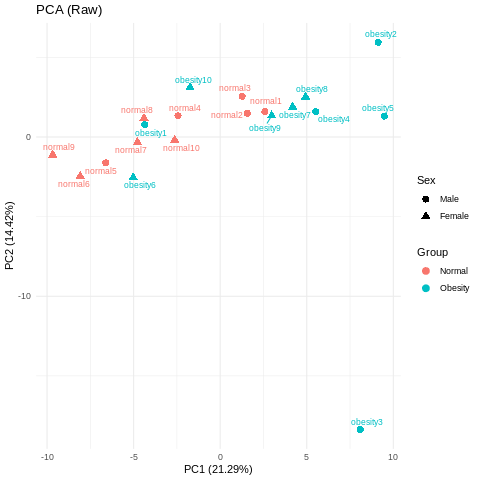

In [ ]:
# PCA visualization
# Missing values were median-imputed only
# DDA-LFQ missingness reflects mixed mechanisms such as MAR and MNAR
# MAR (Missing At Random): missingness related to observed factors, not the true value itself
# MNAR (Missing Not At Random): missingness related to the underlying value (e.g., low abundance below detection)
# Downstream statistical analyses were performed without imputation to avoid bias and inflated false positives (limma also allows NA)

%%R

lfq_pca <- lfq_log2
for (i in seq_len(ncol(lfq_pca))) {
  med <- median(lfq_pca[, i], na.rm = TRUE)
  lfq_pca[is.na(lfq_pca[, i]), i] <- med
}

pca_raw <- prcomp(t(lfq_pca), scale. = TRUE)

pve_raw <- (pca_raw$sdev^2) / sum(pca_raw$sdev^2)
pc1_lab_raw <- paste0("PC1 (", round(100 * pve_raw[1], 2), "%)")
pc2_lab_raw <- paste0("PC2 (", round(100 * pve_raw[2], 2), "%)")

pca_df_raw <- data.frame(
  Sample = sample_names,
  PC1 = -pca_raw$x[,1],
  PC2 = pca_raw$x[,2],
  Group = group,
  Sex = sex
)

ggplot(pca_df_raw, aes(PC1, PC2, color = Group, shape = Sex)) +
  geom_point(size = 3) +
  geom_text_repel(aes(label = Sample),
                  size = 3,
                  show.legend = FALSE) +
  labs(x = pc1_lab_raw,
       y = pc2_lab_raw,
       title = "PCA (Raw)") +
  theme_minimal()

In addition: Warning message:
Partial NA coefficients for 1 probe(s) 


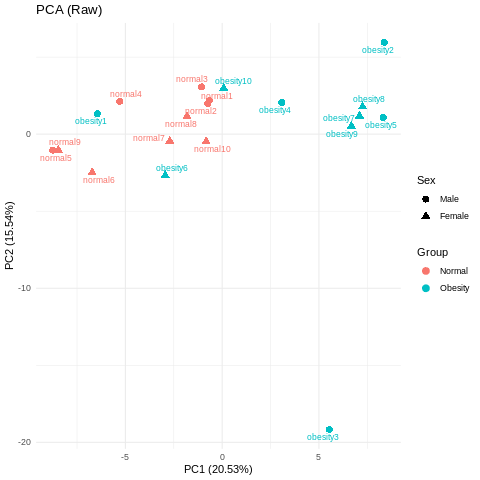

In [ ]:
# Remove sex-related batch effects while preserving group effects
# Batch correction improved group separation compared to raw PCA
# Batch-corrected data were used for downstream analyses

# "Warning message: Partial NA coefficients for 1 probe(s)"
# This warning message is common and safe to ignore when only a small number of probes are affected

%%R

lfq_adj <- removeBatchEffect(as.matrix(lfq_log2),
                             batch = sex,
                             design = model.matrix(~ group))

lfq_adj_pca <- lfq_adj
for (i in seq_len(ncol(lfq_adj_pca))) {
  med <- median(lfq_adj_pca[, i], na.rm = TRUE)
  lfq_adj_pca[is.na(lfq_adj_pca[, i]), i] <- med
}

pca_adj <- prcomp(t(lfq_adj_pca), scale. = TRUE)

pve_adj <- (pca_adj$sdev^2) / sum(pca_adj$sdev^2)
pc1_lab_adj <- paste0("PC1 (", round(100 * pve_adj[1], 2), "%)")
pc2_lab_adj <- paste0("PC2 (", round(100 * pve_adj[2], 2), "%)")

pca_df_adj <- data.frame(
  Sample = sample_names,
  PC1 = pca_adj$x[,1],
  PC2 = pca_adj$x[,2],
  Group = group,
  Sex = sex
)

ggplot(pca_df_adj, aes(PC1, PC2, color = Group, shape = Sex)) +
  geom_point(size = 3) +
  geom_text_repel(aes(label = Sample),
                  size = 3,
                  show.legend = FALSE) +
  labs(x = pc1_lab_adj,
       y = pc2_lab_adj,
       title = "PCA (Raw)") +
  theme_minimal()

In [ ]:
# Differential protein result table from limma model
# Includes protein identifiers, log2 intensities, and limma statistics

%%R

design <- model.matrix(~ group + sex)

fit <- lmFit(lfq_log2, design)
fit <- eBayes(fit)

coef_name <- grep("^group", colnames(design), value = TRUE)[1]

res <- topTable(
  fit,
  coef = coef_name,
  number = Inf,
  adjust.method = "BH",
  sort.by = "none"
)

anno <- pg[rownames(res), c("Protein IDs","Gene names")]
result <- cbind(anno, lfq_log2[rownames(res), ], res)

head(result)

                                                                         Protein IDs
1                                                                         A0A075B6J9
2                                                                  A0A075B6K5;P80748
3 P01615;A0A075B6P5;P01614;A0A087WW87;P06310;A2NJV5;A0A0A0MRZ7;A0A075B6S6;A0A075B6S2
4                                                              A0A0C4DH68;A0A075B6R9
5                                                   A0A0C4DH67;A0A0C4DH69;A0A075B6S5
6                                                                         A0A087WSY6
                                                                             Gene names
1                                                                              IGLV2-18
2                                                                      IGLV3-9;IGLV3-21
3 IGKV2D-28;IGKV2-28;IGKV2D-40;IGKV2-40;IGKV2-30;IGKV2-29;IGKV2D-26;IGKV2D-30;IGKV2D-29
4                                                    

In addition: Warning message:
Partial NA coefficients for 1 probe(s) 


In [ ]:
# Create representative gene labels
# Use the first gene name or Protein ID when gene names are missing to make labeling easier to read.

%%R

result$Gene_short <- ifelse(
  is.na(result$`Gene names`) | result$`Gene names` == "",
  result$`Protein IDs`,
  sub(";.*", "", result$`Gene names`)
)

In [ ]:
# Define FDR threshold (0.1) as cutoff for differential proteins

%%R

FDR <- 0.1

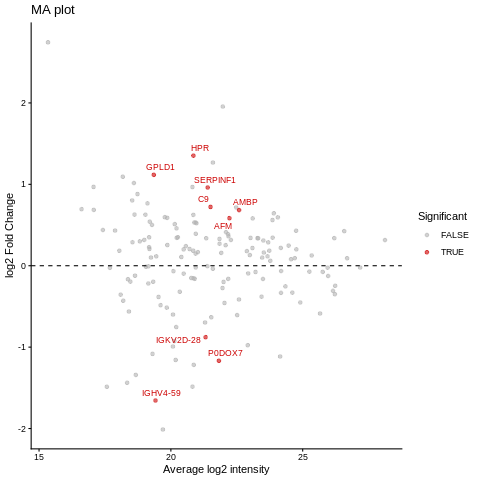

In [ ]:
# Generate MA plot using average expression and logFC
# Define significant proteins by FDR and label them with representative gene names

# LFC > 0 indicates proteins upregulated in obesity
# LFC < 0 indicates proteins downregulated in obesity

%%R

result$neglog10FDR <- -log10(result$adj.P.Val)

avg_expr <- rowMeans(lfq_log2, na.rm = TRUE)

ma_df <- result
ma_df$A <- avg_expr
ma_df$Significant <- ma_df$adj.P.Val < FDR

ggplot(ma_df, aes(A, logFC, color = Significant)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_text_repel(
    data = ma_df[ma_df$adj.P.Val < FDR, ],
    aes(A, logFC, label = Gene_short),
    size = 3,
    max.overlaps = Inf,
    show.legend = FALSE
  ) +
  scale_color_manual(values = c("grey70","red3")) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_classic() +
  labs(
    title = "MA plot",
    x = "Average log2 intensity",
    y = "log2 Fold Change"
  )

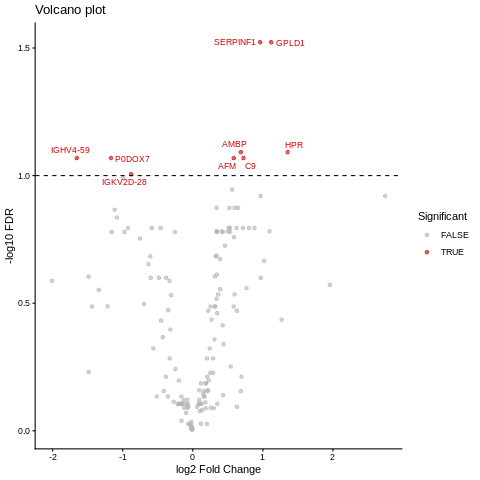

In [ ]:
# Generate volcano plot using logFC and −log10 FDR
# Define significant proteins by FDR, label gene names, and display FDR cutoff line

# LFC > 0 indicates proteins upregulated in obesity
# LFC < 0 indicates proteins downregulated in obesity

%%R

vol_df <- result
vol_df$Significant <- vol_df$adj.P.Val < FDR

ggplot(vol_df, aes(logFC, neglog10FDR, color = Significant)) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_text_repel(
    data = vol_df[vol_df$adj.P.Val < FDR, ],
    aes(logFC, neglog10FDR, label = Gene_short),
    size = 3,
    max.overlaps = Inf,
    show.legend = FALSE
  ) +
  scale_color_manual(values = c("grey70","red3")) +
  geom_hline(yintercept = -log10(FDR), linetype = "dashed") +
  theme_classic() +
  labs(
    title = "Volcano plot",
    x = "log2 Fold Change",
    y = "-log10 FDR"
  )

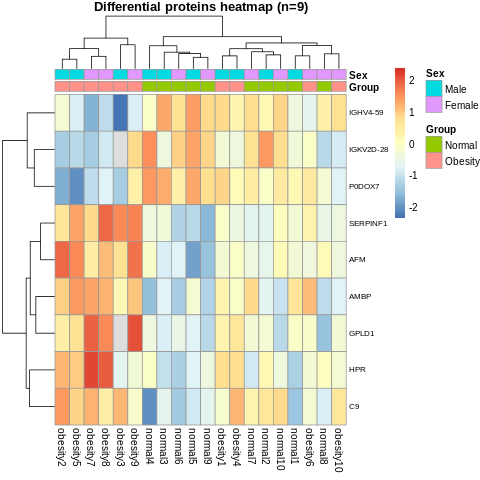

In [ ]:
# Visualize intensity distribution of differential proteins using a heatmap

%%R

sig_ids <- rownames(result)[result$adj.P.Val < FDR]

mat_sig <- lfq_adj[sig_ids, , drop = FALSE]

gene_lab <- result[sig_ids, "Gene_short"]
rownames(mat_sig) <- gene_lab

anno_col <- data.frame(
  Group = group,
  Sex = sex
)
rownames(anno_col) <- colnames(mat_sig)

pheatmap(
  mat_sig,
  scale = "row",
  annotation_col = anno_col,
  show_rownames = TRUE,
  clustering_method = "complete",
  fontsize_row = 8,
  main = "Differential proteins heatmap (n=9)"
)

**Differential proteins**

Upregulated in obesity (logFC > 0):
SERPINF1, GPLD1, AMBP, AFM, HPR, C9

Downregulated in obesity (logFC < 0):
IGKV2D-28, IGHV4-59, PODXL7

SERPINF1 is marker of increased adipose tissue activity
→ insulin resistance impaired → metabolic dysregulation → obesity progression

(Geyer, P. E. et al. Proteomics reveals the effects of sustained weight loss on the human plasma proteome. Molecular Systems Biology 12, 901 (2016).)

In addition: Warning message:
In bitr(result$Gene_short, fromType = "SYMBOL", toType = "ENTREZID",  :
  4.46% of input gene IDs are fail to map...


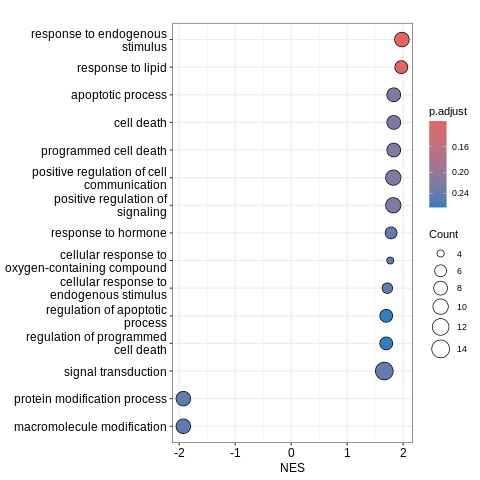

In [ ]:
# Perform GO-BP(Biological Process) GSEA using gene list ranked by t statistic
# Convert core enriched genes to gene symbols and visualize key pathways

# "Warning message: In bitr(result$Gene_short, fromType = "SYMBOL", toType = "ENTREZID", 4.46% of input gene IDs are fail to map...""
# Some gene symbols may fail ENTREZID mapping due to aliases or protein group annotation
# This is common in proteomics and does not affect GSEA when the rate is low

%%R

gene_map <- suppressMessages(
  bitr(
    result$Gene_short,
    fromType = "SYMBOL",
    toType = "ENTREZID",
    OrgDb = org.Hs.eg.db
  )
)

gene_df <- merge(
  data.frame(SYMBOL = result$Gene_short, t = result$t),
  gene_map,
  by = "SYMBOL"
)

gene_df <- gene_df[!duplicated(gene_df$ENTREZID), ]

geneList <- gene_df$t
names(geneList) <- gene_df$ENTREZID
geneList <- sort(geneList, decreasing = TRUE)

gsea_bp <- gseGO(
  geneList = geneList,
  OrgDb = org.Hs.eg.db,
  ont = "BP",
  keyType = "ENTREZID",
  minGSSize = 5,
  maxGSSize = 500,
  pvalueCutoff = 0.4,
  verbose = FALSE
)

gsea_bp_res <- as.data.frame(gsea_bp)

core_list <- strsplit(gsea_bp_res$core_enrichment, "/")

core_symbol <- lapply(core_list, function(x){
  id <- suppressMessages(
    bitr(
      x,
      fromType = "ENTREZID",
      toType = "SYMBOL",
      OrgDb = org.Hs.eg.db
    )
  )
  paste(unique(id$SYMBOL), collapse = "/")
})

gsea_bp_res$core_enrichment_SYMBOL <- unlist(core_symbol)

dotplot(gsea_bp, showCategory = 15, x = "NES")

**Significantly enriched GO terms**

Upregulated in obesity (NES >0) : response to lipid, response to endogenous stimulus

Lipid excess → lipotoxic stress and inflammatory signaling → adipose dysfunction and insulin resistance → obesity progression

(Geyer, P. E. et al. Proteomics reveals the effects of sustained weight loss on the human plasma proteome. Molecular Systems Biology 12, 901 (2016).)